# Decision tree met Gini 

Je kunt een library gebruiken om Decision tree te trainen. Hieronder geven we een voorbeeld voor de MNIST database.

Let er op dat de enige features die hier worden gebruikt pixelwaardes op locaties zijn. Dus:

- enkel rauwe pixel intensiteiten
- 1 pixel = 1 numerical feature
- Er is geen featue die gaat over ruimtelijk begrip, filtering, of anderen (eg symmetrie in verticale as, aantal gaten etc)

Importeer de libaries, laad de mnist db en spilt test en training set.

In [17]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


# Load MNIST from OpenML
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist['data']
y = mnist['target'] 
y = y.astype(int)       


In [18]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Trainen van een decision tree is nu heel simpel. We gebruiken ***max_depth = 20*** om er voor te zorgen dat de decision tree niet overtraint. 

Wat is overtrainen hier en waarom denk je dat het nodig is?

- Overtrainen betekent dat het model de trainingsdata te goed leert, inclusief uitschieters en toevallige patronen. Daardoor generaliseert het model slecht naar nieuwe en ongeleerde data. Door de `max_depth` te beperken tot 20 voorkom je dat de boom overtraint.

In [ ]:

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,    
    random_state=42
)

dt.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

Doe nu de voorspellingen en laat de precisie zien.

In [20]:
y_pred = dt.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy on MNIST:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy on MNIST: 0.8728571428571429

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1343
           1       0.94      0.95      0.95      1600
           2       0.86      0.84      0.85      1380
           3       0.84      0.84      0.84      1433
           4       0.84      0.87      0.86      1295
           5       0.83      0.82      0.83      1273
           6       0.90      0.91      0.90      1396
           7       0.90      0.91      0.91      1503
           8       0.83      0.80      0.81      1357
           9       0.82      0.84      0.83      1420

    accuracy                           0.87     14000
   macro avg       0.87      0.87      0.87     14000
weighted avg       0.87      0.87      0.87     14000



- Zoek uit waar de waardes in de classification repoirt voor staan.

  - Precision: Precision meet hoe vaak een positieve voorspelling juist is. Oftewel hoeveel van de voorspelde labels correct zijn.
  - Recall: Recall geeft aan welk percentage van de daadwerkelijk positieve getallen correct is herkend door het model.
  - Support: Hoeveelheid testdata
  - f1-score: f1-score is 1 score die de recall en precision combineert en laat zien hoe goed het model het in het algemeen doet.

- Is de waarde hoger dan wat jij in je eerdere Decision tree had? Waarom denk je?
    - Ja, de waarde is veel hoger. Dit komt doordat het model beter is getraind, want onze decision treek kijkt slechts naar 8 features, en deze kijkt naar 784 features (elke pixel is er 1). Hierdoor is de accuratie hoger.

Je kunt de boom ook met een library laten zien. Let er op dat je een limiet instelt op hoeveel lagen je toont (gebruik **max_depth=klein_getal**)

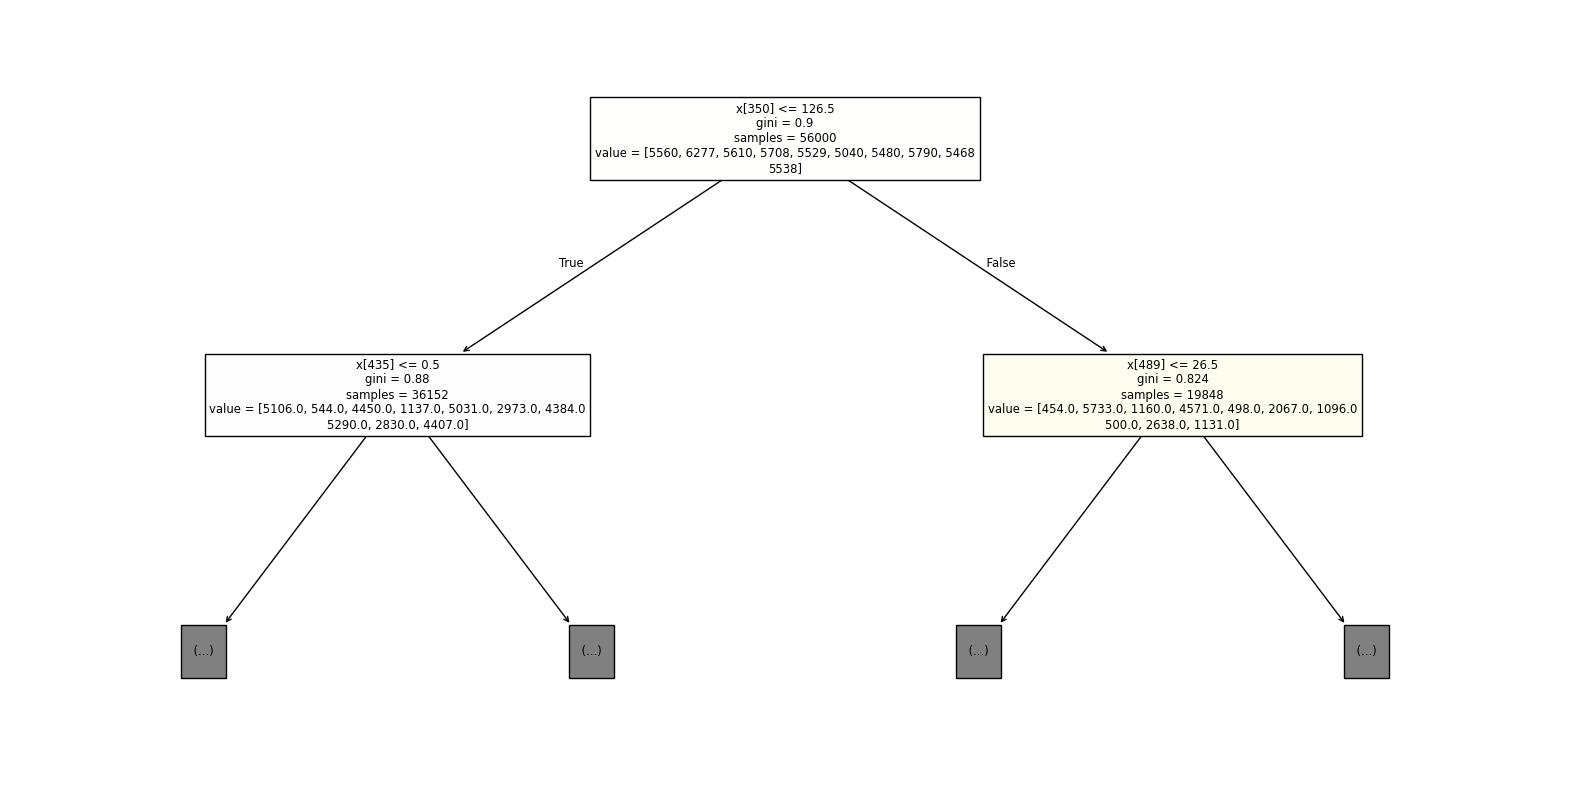

In [21]:

from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt, max_depth=1, filled=True)
plt.show()


Laten we nu kijken of je betere resultaten kunt krijgen uit de features die je zelf eerder hebt bedacht.

In [22]:
def get_percentage(num1, num2):
    return float(round((num1 / num2) * 100, 2))

def percentage_dark_pixels(img):
    # Hoog percentage: Veel zwart, veel achtergrond, weinig cijfer opp
    # Laag percentage: Weinig zwart, weinig achtergrond, veel cijfer opp

    total_pixels = img.size
    dark_pixels = np.sum(img == 0)

    return get_percentage(dark_pixels, total_pixels)


def get_top_bottom_ratio(img):
    # Percentage > 100: Boven lichter dan onder (cijfer zit meer boven)
    # Percentage < 100: Onder lichter dan boven (cijfer zit meer onder)

    top = img[: img.shape[0] // 2, :]
    bottom = img[img.shape[0] // 2 :, :]
    top_sum = np.sum(top)
    bottom_sum = np.sum(bottom)

    if bottom_sum == 0:
        return 100.0
    return get_percentage(top_sum, bottom_sum)


def get_left_right_ratio(img):
    # Percentage > 100: links lichter dan rechts (cijfer zit meer links)
    # Percentage < 100: rechts lichter dan links (cijfer zit meer rechts)

    left = img[:, : img.shape[1] // 2]
    right = img[:, img.shape[1] // 2 :]

    left_sum = np.sum(left)
    right_sum = np.sum(right)

    if right_sum == 0:
        return 100.0
    return get_percentage(left_sum, right_sum)


def get_height_and_width_of_shape(img):
    # In pixels

    rows = np.any(img != 0, axis=1)
    cols = np.any(img != 0, axis=0)

    row_indices = np.where(rows)[0]
    col_indices = np.where(cols)[0]

    if len(row_indices) == 0 or len(col_indices) == 0:
        return 0, 0

    height = row_indices[-1] - row_indices[0] + 1
    width = col_indices[-1] - col_indices[0] + 1

    return int(height), int(width)


def get_symmetry(img):
    # Hoog percentage: Cijfer is symetrisch
    # Laag percentage: Cijfer is niet symetrisch

    left = img[: img.shape[0] // 2, :]
    right = img[img.shape[0] // 2 :, :]

    left_flipped = np.fliplr(left)

    matches = np.sum(left_flipped == right)
    total_pixels = left_flipped.size

    return get_percentage(matches, total_pixels)


def get_stdev_and_average(img):
    # Hoog gemiddelde: meer lichte pixels (cijfer is dik, veel cijfer pixels)
    # Laag gemiddelde: minder lichte pixels (cijfer is dun, weinig cijfer pixels)

    # Lage stdev: Weinig variatie in pixelwaarden
    # Hoge stdev: Veel variatie in pixelwaarden

    average = np.average(img)
    stdev = np.std(img)

    return round(float(average), 2), round(float(stdev), 2)



def extract_features(img):
    features = []
    features.append(percentage_dark_pixels(img))
    features.append(get_top_bottom_ratio(img))
    features.append(get_left_right_ratio(img))
    
    height, width = get_height_and_width_of_shape(img)
    features.append(height)
    features.append(width)
    
    features.append(get_symmetry(img))
    
    average, stdev = get_stdev_and_average(img)
    features.append(average)
    features.append(stdev)
    
    return features
    
def extract_features_batch(X_flat):
    imgs = X_flat.reshape(-1, 28, 28)
    feature_list = []

    for img in imgs:
        feats = extract_features(img)   # Deze hebben jullie eerder gemaakt! Gebruik hier je oude extract_features functie
        feature_list.append(feats)

    return np.array(feature_list)       # shape: (n_samples, n_student_features)

#combineer de standaard features met jouw nieuwe features
# Dit is dus wat we hadden: (70000, 784)
# stel je hebt zelf 11 features aangemaakt
# Dan is dit wat het wordt: (70000, 784 + 11)

x_students = extract_features_batch(X)

X_combined = np.hstack([X, x_students])
print("Combined shape:", X_combined.shape)

X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

dt.fit(X_train_combined, y_train)

y_pred_combined = dt.predict(X_test_combined)


acc = accuracy_score(y_test, y_pred_combined)
print("Decision Tree Accuracy on MNIST:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_combined))

Combined shape: (70000, 792)
Decision Tree Accuracy on MNIST: 0.8771428571428571

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1343
           1       0.95      0.96      0.95      1600
           2       0.88      0.87      0.87      1380
           3       0.83      0.82      0.83      1433
           4       0.85      0.88      0.87      1295
           5       0.81      0.82      0.82      1273
           6       0.92      0.92      0.92      1396
           7       0.90      0.90      0.90      1503
           8       0.83      0.83      0.83      1357
           9       0.84      0.83      0.83      1420

    accuracy                           0.88     14000
   macro avg       0.88      0.88      0.88     14000
weighted avg       0.88      0.88      0.88     14000



- Heb je nu betere resultaten?
   - De waarde is 0,01 hoger dan in onze eerdere decision tree met de features. Dit komt doordat er iets meer variabelen beschikbaar zijn om de voorspelling op te baseren. Echter, de toename in accuratie is minimal in ons geval.